In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/gravity_simulator
!ls -l

In [23]:
%%bash
cat > gravity_cuda_sim.cu << 'EOF'
#include <cstdio>
#include <cmath>

#define G 6.67430e-11
#define SOFT 1e9
#define DAY 86400.0

struct Body {
    double x, y, z;
    double vx, vy, vz;
    double mass;
};

__global__
void computeAccel(Body *b, double *ax, double *ay, double *az, int n)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    double xi = b[i].x, yi = b[i].y, zi = b[i].z;

    double axi = 0, ayi = 0, azi = 0;

    for (int j = 0; j < n; j++)
    {
        if (i == j) continue;

        double dx = b[j].x - xi;
        double dy = b[j].y - yi;
        double dz = b[j].z - zi;

        double dist2 = dx*dx + dy*dy + dz*dz + SOFT*SOFT;
        double invDist = rsqrt(dist2);
        double invDist3 = invDist * invDist * invDist;

        double f = G * b[j].mass * invDist3;

        axi += f * dx;
        ayi += f * dy;
        azi += f * dz;
    }

    ax[i] = axi;
    ay[i] = ayi;
    az[i] = azi;
}

__global__
void updateBodies(Body *b, double *ax, double *ay, double *az, int n, double dt)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    b[i].vx += ax[i] * dt;
    b[i].vy += ay[i] * dt;
    b[i].vz += az[i] * dt;

    b[i].x += b[i].vx * dt;
    b[i].y += b[i].vy * dt;
    b[i].z += b[i].vz * dt;
}

int main()
{
    Body h[2];

    // Sun
    h[0].mass = 1.989e30;
    h[0].x = h[0].y = h[0].z = 0;
    h[0].vx = h[0].vy = h[0].vz = 0;

    // Earth
    h[1].mass = 5.972e24;
    h[1].x = 1.496e11;
    h[1].y = h[1].z = 0;
    h[1].vx = 0;
    h[1].vy = 2.979e4;
    h[1].vz = 0;

    const int n = 2;
    Body *dB;
    double *ax, *ay, *az;

    cudaMalloc(&dB, n * sizeof(Body));
    cudaMalloc(&ax, n * sizeof(double));
    cudaMalloc(&ay, n * sizeof(double));
    cudaMalloc(&az, n * sizeof(double));

    cudaMemcpy(dB, h, n * sizeof(Body), cudaMemcpyHostToDevice);

    dim3 block(256);
    dim3 grid((n + block.x - 1) / block.x);

    double dt = DAY;
    int total = 2000000;

    for (int t = 0; t <= total; t += 100000)
    {
        cudaMemcpy(h, dB, n * sizeof(Body), cudaMemcpyDeviceToHost);
        printf("t=%d\n", t);
        printf("earth = %.3e , %.3e\n", h[1].x, h[1].y);

        computeAccel<<<grid, block>>>(dB, ax, ay, az, n);
        updateBodies<<<grid, block>>>(dB, ax, ay, az, n, dt);
        cudaDeviceSynchronize();
    }

    return 0;
}
EOF

In [17]:
!nvcc -arch=sm_75 gravity_cuda_sim.cu -o gravity_sim

In [18]:
!./gravity_sim

t=0
earth = 1.496e+11 , 0.000e+00
t=100000
earth = 1.496e+11 , 2.574e+09
t=200000
earth = 1.495e+11 , 5.147e+09
t=300000
earth = 1.493e+11 , 7.719e+09
t=400000
earth = 1.492e+11 , 1.029e+10
t=500000
earth = 1.489e+11 , 1.285e+10
t=600000
earth = 1.487e+11 , 1.542e+10
t=700000
earth = 1.484e+11 , 1.797e+10
t=800000
earth = 1.480e+11 , 2.053e+10
t=900000
earth = 1.476e+11 , 2.307e+10
t=1000000
earth = 1.472e+11 , 2.561e+10
t=1100000
earth = 1.467e+11 , 2.814e+10
t=1200000
earth = 1.462e+11 , 3.067e+10
t=1300000
earth = 1.456e+11 , 3.318e+10
t=1400000
earth = 1.450e+11 , 3.569e+10
t=1500000
earth = 1.443e+11 , 3.818e+10
t=1600000
earth = 1.436e+11 , 4.066e+10
t=1700000
earth = 1.429e+11 , 4.313e+10
t=1800000
earth = 1.421e+11 , 4.559e+10
t=1900000
earth = 1.412e+11 , 4.804e+10
t=2000000
earth = 1.404e+11 , 5.047e+10


In [24]:
%%bash
cat > gravity_cuda_planets.cu << 'EOF'
#include <cstdio>
#include <cmath>

#define G 6.67430e-11
#define SOFT 1e9
#define DAY 86400.0

struct Body {
    double x, y, z;
    double vx, vy, vz;
    double mass;
};

__global__
void computeAccel(Body *b, double *ax, double *ay, double *az, int n)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    double xi = b[i].x, yi = b[i].y, zi = b[i].z;
    double axi = 0, ayi = 0, azi = 0;

    for (int j = 0; j < n; j++)
    {
        if (i == j) continue;

        double dx = b[j].x - xi;
        double dy = b[j].y - yi;
        double dz = b[j].z - zi;

        double dist2 = dx*dx + dy*dy + dz*dz + SOFT*SOFT;
        double invDist = rsqrt(dist2);
        double invDist3 = invDist * invDist * invDist;

        double f = G * b[j].mass * invDist3;

        axi += f * dx;
        ayi += f * dy;
        azi += f * dz;
    }

    ax[i] = axi;
    ay[i] = ayi;
    az[i] = azi;
}

__global__
void updateBodies(Body *b, double *ax, double *ay, double *az, int n, double dt)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    b[i].vx += ax[i] * dt;
    b[i].vy += ay[i] * dt;
    b[i].vz += az[i] * dt;

    b[i].x += b[i].vx * dt;
    b[i].y += b[i].vy * dt;
    b[i].z += b[i].vz * dt;
}

int main()
{
    const int n = 4;  // Sun, Mercury, Earth, Jupiter
    Body h[n];

    // Sun
    h[0].mass = 1.989e30;
    h[0].x = h[0].y = h[0].z = 0;
    h[0].vx = h[0].vy = h[0].vz = 0;

    // Mercury
    h[1].mass = 3.3011e23;
    h[1].x = 5.7909e10;
    h[1].y = h[1].z = 0;
    h[1].vx = 0;
    h[1].vy = 4.788e4; // orbital velocity
    h[1].vz = 0;

    // Earth
    h[2].mass = 5.972e24;
    h[2].x = 1.4959787e11;
    h[2].y = h[2].z = 0;
    h[2].vx = 0;
    h[2].vy = 2.979e4;
    h[2].vz = 0;

    // Jupiter
    h[3].mass = 1.898e27;
    h[3].x = 7.78547e11;
    h[3].y = h[3].z = 0;
    h[3].vx = 0;
    h[3].vy = 1.306e4;
    h[3].vz = 0;

    Body *dB;
    double *ax, *ay, *az;

    cudaMalloc(&dB, n * sizeof(Body));
    cudaMalloc(&ax, n * sizeof(double));
    cudaMalloc(&ay, n * sizeof(double));
    cudaMalloc(&az, n * sizeof(double));

    cudaMemcpy(dB, h, n * sizeof(Body), cudaMemcpyHostToDevice);

    dim3 block(256);
    dim3 grid((n + block.x - 1) / block.x);

    double dt = DAY;
    int total_days = 400;  // about a year for Earth

    for (int day = 0; day <= total_days; day++)
    {
        cudaMemcpy(h, dB, n * sizeof(Body), cudaMemcpyDeviceToHost);

        printf("t=%d days\n", day);
        printf("Sun      %.3e, %.3e\n", h[0].x, h[0].y);
        printf("Mercury  %.3e, %.3e\n", h[1].x, h[1].y);
        printf("Earth    %.3e, %.3e\n", h[2].x, h[2].y);
        printf("Jupiter  %.3e, %.3e\n\n", h[3].x, h[3].y);

        computeAccel<<<grid, block>>>(dB, ax, ay, az, n);
        updateBodies<<<grid, block>>>(dB, ax, ay, az, n, dt);
        cudaDeviceSynchronize();
    }

    return 0;
}
EOF

In [19]:
!nvcc -arch=sm_75 gravity_cuda_planets.cu -o gravity_planets

In [20]:
!./gravity_planets

t=0 days
Sun      0.000e+00, 0.000e+00
Mercury  5.791e+10, 0.000e+00
Earth    1.496e+11, 0.000e+00
Jupiter  7.785e+11, 0.000e+00

t=1 days
Sun      1.742e+03, 0.000e+00
Mercury  5.761e+10, 4.137e+09
Earth    1.496e+11, 2.574e+09
Jupiter  7.785e+11, 1.128e+09

t=2 days
Sun      5.226e+03, 8.078e+00
Mercury  5.702e+10, 8.252e+09
Earth    1.495e+11, 5.147e+09
Jupiter  7.785e+11, 2.257e+09

t=3 days
Sun      1.045e+04, 3.235e+01
Mercury  5.614e+10, 1.233e+10
Earth    1.493e+11, 7.719e+09
Jupiter  7.785e+11, 3.385e+09

t=4 days
Sun      1.742e+04, 8.095e+01
Mercury  5.496e+10, 1.633e+10
Earth    1.492e+11, 1.029e+10
Jupiter  7.785e+11, 4.514e+09

t=5 days
Sun      2.613e+04, 1.620e+02
Mercury  5.349e+10, 2.026e+10
Earth    1.489e+11, 1.285e+10
Jupiter  7.785e+11, 5.642e+09

t=6 days
Sun      3.658e+04, 2.836e+02
Mercury  5.174e+10, 2.407e+10
Earth    1.487e+11, 1.542e+10
Jupiter  7.785e+11, 6.770e+09

t=7 days
Sun      4.877e+04, 4.538e+02
Mercury  4.971e+10, 2.776e+10
Earth    1.484e+11, 1

In [22]:
!nvprof ./gravity_planets


==8129== NVPROF is profiling process 8129, command: ./gravity_planets
t=0 days
Sun      0.000e+00, 0.000e+00
Mercury  5.791e+10, 0.000e+00
Earth    1.496e+11, 0.000e+00
Jupiter  7.785e+11, 0.000e+00

t=1 days
Sun      1.742e+03, 0.000e+00
Mercury  5.761e+10, 4.137e+09
Earth    1.496e+11, 2.574e+09
Jupiter  7.785e+11, 1.128e+09

t=2 days
Sun      5.226e+03, 8.078e+00
Mercury  5.702e+10, 8.252e+09
Earth    1.495e+11, 5.147e+09
Jupiter  7.785e+11, 2.257e+09

t=3 days
Sun      1.045e+04, 3.235e+01
Mercury  5.614e+10, 1.233e+10
Earth    1.493e+11, 7.719e+09
Jupiter  7.785e+11, 3.385e+09

t=4 days
Sun      1.742e+04, 8.095e+01
Mercury  5.496e+10, 1.633e+10
Earth    1.492e+11, 1.029e+10
Jupiter  7.785e+11, 4.514e+09

t=5 days
Sun      2.613e+04, 1.620e+02
Mercury  5.349e+10, 2.026e+10
Earth    1.489e+11, 1.285e+10
Jupiter  7.785e+11, 5.642e+09

t=6 days
Sun      3.658e+04, 2.836e+02
Mercury  5.174e+10, 2.407e+10
Earth    1.487e+11, 1.542e+10
Jupiter  7.785e+11, 6.770e+09

t=7 days
Sun      4.

In [25]:
%%bash
cat > gravity_cuda_planets_log.cu << 'EOF'
#include <cstdio>
#include <cmath>

#define G 6.67430e-11
#define SOFT 1e9
#define DAY 86400.0

struct Body {
    double x, y, z;
    double vx, vy, vz;
    double mass;
};

__global__
void computeAccel(Body *b, double *ax, double *ay, double *az, int n)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    double xi = b[i].x, yi = b[i].y, zi = b[i].z;
    double axi = 0, ayi = 0, azi = 0;

    for (int j = 0; j < n; j++)
    {
        if (i == j) continue;

        double dx = b[j].x - xi;
        double dy = b[j].y - yi;
        double dz = b[j].z - zi;

        double dist2 = dx*dx + dy*dy + dz*dz + SOFT*SOFT;
        double invDist = rsqrt(dist2);
        double invDist3 = invDist * invDist * invDist;

        double f = G * b[j].mass * invDist3;

        axi += f * dx;
        ayi += f * dy;
        azi += f * dz;
    }

    ax[i] = axi;
    ay[i] = ayi;
    az[i] = azi;
}

__global__
void updateBodies(Body *b, double *ax, double *ay, double *az, int n, double dt)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    b[i].vx += ax[i] * dt;
    b[i].vy += ay[i] * dt;
    b[i].vz += az[i] * dt;

    b[i].x += b[i].vx * dt;
    b[i].y += b[i].vy * dt;
    b[i].z += b[i].vz * dt;
}

int main()
{
    const int n = 4;  // Sun, Mercury, Earth, Jupiter
    Body h[n];

    // Sun
    h[0].mass = 1.989e30;
    h[0].x = h[0].y = h[0].z = 0;
    h[0].vx = h[0].vy = h[0].vz = 0;

    // Mercury
    h[1].mass = 3.3011e23;
    h[1].x = 5.7909e10;
    h[1].y = h[1].z = 0;
    h[1].vx = 0;
    h[1].vy = 4.788e4;
    h[1].vz = 0;

    // Earth
    h[2].mass = 5.972e24;
    h[2].x = 1.4959787e11;
    h[2].y = h[2].z = 0;
    h[2].vx = 0;
    h[2].vy = 2.979e4;
    h[2].vz = 0;

    // Jupiter
    h[3].mass = 1.898e27;
    h[3].x = 7.78547e11;
    h[3].y = h[3].z = 0;
    h[3].vx = 0;
    h[3].vy = 1.306e4;
    h[3].vz = 0;

    Body *dB;
    double *ax, *ay, *az;

    cudaMalloc(&dB, n * sizeof(Body));
    cudaMalloc(&ax, n * sizeof(double));
    cudaMalloc(&ay, n * sizeof(double));
    cudaMalloc(&az, n * sizeof(double));

    cudaMemcpy(dB, h, n * sizeof(Body), cudaMemcpyHostToDevice);

    dim3 block(256);
    dim3 grid((n + block.x - 1) / block.x);

    FILE *fp = fopen("orbitlog.csv", "w");
    fprintf(fp, "Sun_x,Sun_y, Merc_x,Merc_y, Earth_x,Earth_y, Jup_x,Jup_y\n");

    double dt = DAY;
    int total_days = 400;

    for (int day = 0; day <= total_days; day++)
    {
        cudaMemcpy(h, dB, n * sizeof(Body), cudaMemcpyDeviceToHost);

        fprintf(fp, "%.6e,%.6e, %.6e,%.6e, %.6e,%.6e, %.6e,%.6e\n",
                h[0].x, h[0].y,
                h[1].x, h[1].y,
                h[2].x, h[2].y,
                h[3].x, h[3].y);

        computeAccel<<<grid, block>>>(dB, ax, ay, az, n);
        updateBodies<<<grid, block>>>(dB, ax, ay, az, n, dt);
        cudaDeviceSynchronize();
    }

    fclose(fp);
    return 0;
}
EOF

In [26]:
!nvcc -arch=sm_75 gravity_cuda_planets_log.cu -o gravity_planets_log

In [21]:
!./gravity_planets_log


/bin/bash: line 1: ./gravity_planets_log: Permission denied


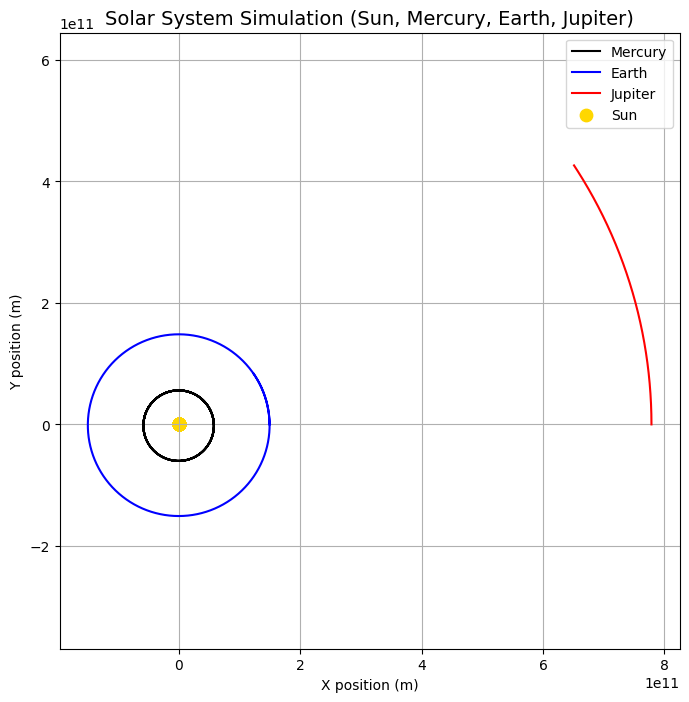

In [27]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("orbitlog.csv", delimiter=",", skiprows=1)

sun_x, sun_y = data[:,0], data[:,1]
mer_x, mer_y = data[:,2], data[:,3]
earth_x, earth_y = data[:,4], data[:,5]
jup_x, jup_y = data[:,6], data[:,7]

plt.figure(figsize=(8,8))
plt.title("Solar System Simulation (Sun, Mercury, Earth, Jupiter)", fontsize=14)

plt.plot(mer_x, mer_y, 'k', label="Mercury")
plt.plot(earth_x, earth_y, 'b', label="Earth")
plt.plot(jup_x, jup_y, 'r', label="Jupiter")
plt.scatter(sun_x, sun_y, color='gold', s=80, label="Sun")

plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


In [28]:
%%bash
cat > gravity_bonus.cu << 'EOF'
#include <cstdio>
#include <cmath>

#define G    6.67430e-11
#define SOFT 1e9 //prevents division by zero and huge spikes when bodies are too close
#define DAY  86400.0

struct Body {
    double x, y, z;
    double vx, vy, vz;
    double mass;
};

// SHARED-MEMORY TILED KERNEL
__global__
void computeAccelTiled(Body *b, double *ax, double *ay, double *az, int n)
{
    extern __shared__ Body tile[];   // tile of bodies loaded into shared memory

    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    double xi = b[i].x, yi = b[i].y, zi = b[i].z;
    double axi = 0, ayi = 0, azi = 0;

    // Loop over the bodies in chunks of blockDim.x
    for (int tileStart = 0; tileStart < n; tileStart += blockDim.x)
    {
        int j = tileStart + threadIdx.x;

        // Load tile into shared memory
        if (j < n)
            tile[threadIdx.x] = b[j];

        __syncthreads();

        // Compute forces using shared memory tile
        int tileSize = min(blockDim.x, n - tileStart);

        for (int k = 0; k < tileSize; k++)
        {
            if (i == tileStart + k) continue;

            double dx = tile[k].x - xi;
            double dy = tile[k].y - yi;
            double dz = tile[k].z - zi;

            double dist2 = dx*dx + dy*dy + dz*dz + SOFT*SOFT;
            double invDist = rsqrt(dist2);
            double invDist3 = invDist * invDist * invDist;

            double f = G * tile[k].mass * invDist3;

            axi += f * dx;
            ayi += f * dy;
            azi += f * dz;
        }

        __syncthreads();
    }

    ax[i] = axi;
    ay[i] = ayi;
    az[i] = azi;
}


// Update kernel

__global__
void updateBodies(Body *b, double *ax, double *ay, double *az, int n, double dt)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    b[i].vx += ax[i] * dt;
    b[i].vy += ay[i] * dt;
    b[i].vz += az[i] * dt;

    b[i].x += b[i].vx * dt;
    b[i].y += b[i].vy * dt;
    b[i].z += b[i].vz * dt;
}

// Main Simulation: Sun + Mercury + Earth + Jupiter

int main()
{
    const int n = 4;
    Body h[n];

    // Sun
    h[0] = {0,0,0, 0,0,0, 1.989e30};

    // Mercury
    h[1] = {5.7909e10,0,0, 0,4.788e4,0, 3.3011e23};

    // Earth
    h[2] = {1.4959787e11,0,0, 0,2.979e4,0, 5.972e24};

    // Jupiter
    h[3] = {7.78547e11,0,0, 0,1.306e4,0, 1.898e27};

    Body *dB;
    double *ax, *ay, *az;

    cudaMalloc(&dB, n*sizeof(Body));
    cudaMalloc(&ax, n*sizeof(double));
    cudaMalloc(&ay, n*sizeof(double));
    cudaMalloc(&az, n*sizeof(double));

    cudaMemcpy(dB, h, n*sizeof(Body), cudaMemcpyHostToDevice);

    dim3 block(128);
    dim3 grid((n + block.x - 1) / block.x);

    size_t sharedBytes = block.x * sizeof(Body);

    double dt = DAY;
    int total_days = 400;

    for (int t = 0; t <= total_days; t++)
    {
        cudaMemcpy(h, dB, n*sizeof(Body), cudaMemcpyDeviceToHost);

        printf("t=%d days\n", t);
        printf("Sun      %.3e, %.3e\n", h[0].x, h[0].y);
        printf("Mercury  %.3e, %.3e\n", h[1].x, h[1].y);
        printf("Earth    %.3e, %.3e\n", h[2].x, h[2].y);
        printf("Jupiter  %.3e, %.3e\n\n", h[3].x, h[3].y);

        computeAccelTiled<<<grid, block, sharedBytes>>>(dB, ax, ay, az, n);
        updateBodies<<<grid, block>>>(dB, ax, ay, az, n, dt);

        cudaDeviceSynchronize();
    }

    return 0;
}
EOF


In [29]:
!nvcc -arch=sm_75 gravity_bonus.cu -o gravity_bonus


In [30]:
!./gravity_bonus


t=0 days
Sun      0.000e+00, 0.000e+00
Mercury  5.791e+10, 0.000e+00
Earth    1.496e+11, 0.000e+00
Jupiter  7.785e+11, 0.000e+00

t=1 days
Sun      1.742e+03, 0.000e+00
Mercury  5.761e+10, 4.137e+09
Earth    1.496e+11, 2.574e+09
Jupiter  7.785e+11, 1.128e+09

t=2 days
Sun      5.226e+03, 8.078e+00
Mercury  5.702e+10, 8.252e+09
Earth    1.495e+11, 5.147e+09
Jupiter  7.785e+11, 2.257e+09

t=3 days
Sun      1.045e+04, 3.235e+01
Mercury  5.614e+10, 1.233e+10
Earth    1.493e+11, 7.719e+09
Jupiter  7.785e+11, 3.385e+09

t=4 days
Sun      1.742e+04, 8.095e+01
Mercury  5.496e+10, 1.633e+10
Earth    1.492e+11, 1.029e+10
Jupiter  7.785e+11, 4.514e+09

t=5 days
Sun      2.613e+04, 1.620e+02
Mercury  5.349e+10, 2.026e+10
Earth    1.489e+11, 1.285e+10
Jupiter  7.785e+11, 5.642e+09

t=6 days
Sun      3.658e+04, 2.836e+02
Mercury  5.174e+10, 2.407e+10
Earth    1.487e+11, 1.542e+10
Jupiter  7.785e+11, 6.770e+09

t=7 days
Sun      4.877e+04, 4.538e+02
Mercury  4.971e+10, 2.776e+10
Earth    1.484e+11, 1

In [31]:
!nvprof ./gravity_bonus


==9753== NVPROF is profiling process 9753, command: ./gravity_bonus
t=0 days
Sun      0.000e+00, 0.000e+00
Mercury  5.791e+10, 0.000e+00
Earth    1.496e+11, 0.000e+00
Jupiter  7.785e+11, 0.000e+00

t=1 days
Sun      1.742e+03, 0.000e+00
Mercury  5.761e+10, 4.137e+09
Earth    1.496e+11, 2.574e+09
Jupiter  7.785e+11, 1.128e+09

t=2 days
Sun      5.226e+03, 8.078e+00
Mercury  5.702e+10, 8.252e+09
Earth    1.495e+11, 5.147e+09
Jupiter  7.785e+11, 2.257e+09

t=3 days
Sun      1.045e+04, 3.235e+01
Mercury  5.614e+10, 1.233e+10
Earth    1.493e+11, 7.719e+09
Jupiter  7.785e+11, 3.385e+09

t=4 days
Sun      1.742e+04, 8.095e+01
Mercury  5.496e+10, 1.633e+10
Earth    1.492e+11, 1.029e+10
Jupiter  7.785e+11, 4.514e+09

t=5 days
Sun      2.613e+04, 1.620e+02
Mercury  5.349e+10, 2.026e+10
Earth    1.489e+11, 1.285e+10
Jupiter  7.785e+11, 5.642e+09

t=6 days
Sun      3.658e+04, 2.836e+02
Mercury  5.174e+10, 2.407e+10
Earth    1.487e+11, 1.542e+10
Jupiter  7.785e+11, 6.770e+09

t=7 days
Sun      4.87

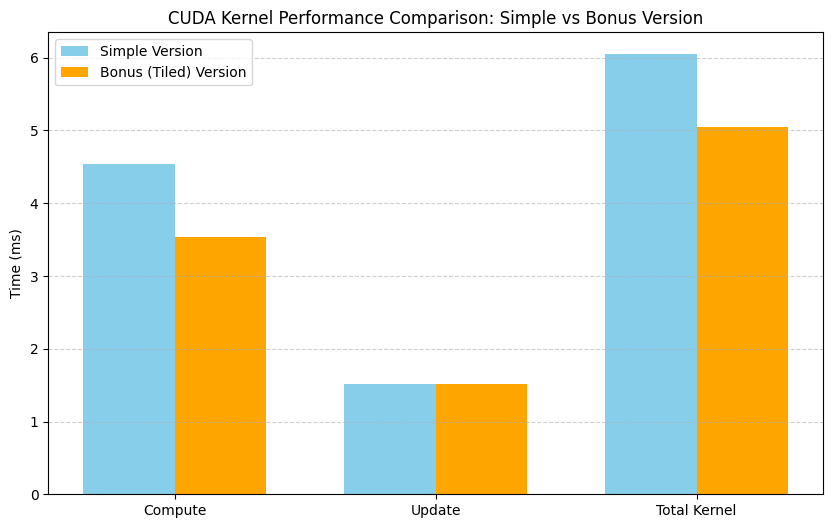

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# Data from your profiler outputs
# ------------------------------

# Simple version (gravity_planets)
simple_compute = 4.5367   # ms
simple_update  = 1.5092   # ms
simple_total   = simple_compute + simple_update

# Bonus version (gravity_bonus)
bonus_compute  = 3.5343   # ms
bonus_update   = 1.5106   # ms
bonus_total    = bonus_compute + bonus_update

labels = ["Compute", "Update", "Total Kernel"]
simple_values = [simple_compute, simple_update, simple_total]
bonus_values  = [bonus_compute, bonus_update, bonus_total]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, simple_values, width, label='Simple Version', color='skyblue')
plt.bar(x + width/2, bonus_values,  width, label='Bonus (Tiled) Version', color='orange')

plt.ylabel("Time (ms)")
plt.title("CUDA Kernel Performance Comparison: Simple vs Bonus Version")
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
